In [7]:
import re
import numpy as np
import matplotlib.pyplot as plt

rng_global = np.random.default_rng(42)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [8]:
def softmax_with_temperature(logits, T=1.0):

    logits = np.asarray(logits, dtype=float) / T
    logits = logits - logits.max()
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum()


kelimeler = ["marul", "nane", "maydanoz", "dereotu", "madımak"]
logits = [1.2, 1.1, 1.0, -0.9, -0.7]


print(f"{'Sıcaklık':<10}" + "".join(f"{k:>10}" for k in kelimeler))


for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
    probs = softmax_with_temperature(logits, T)
    print(f"T={T:<8}" + "".join(f"{p:>10.1%}" for p in probs))


Sıcaklık       marul      nane  maydanoz   dereotu   madımak
T=0.2          50.6%     30.7%     18.6%      0.0%      0.0%
T=0.5          39.6%     32.4%     26.5%      0.6%      0.9%
T=1.0          33.4%     30.2%     27.3%      4.1%      5.0%
T=1.5          29.9%     28.0%     26.2%      7.4%      8.4%
T=3.0          25.4%     24.6%     23.8%     12.6%     13.5%


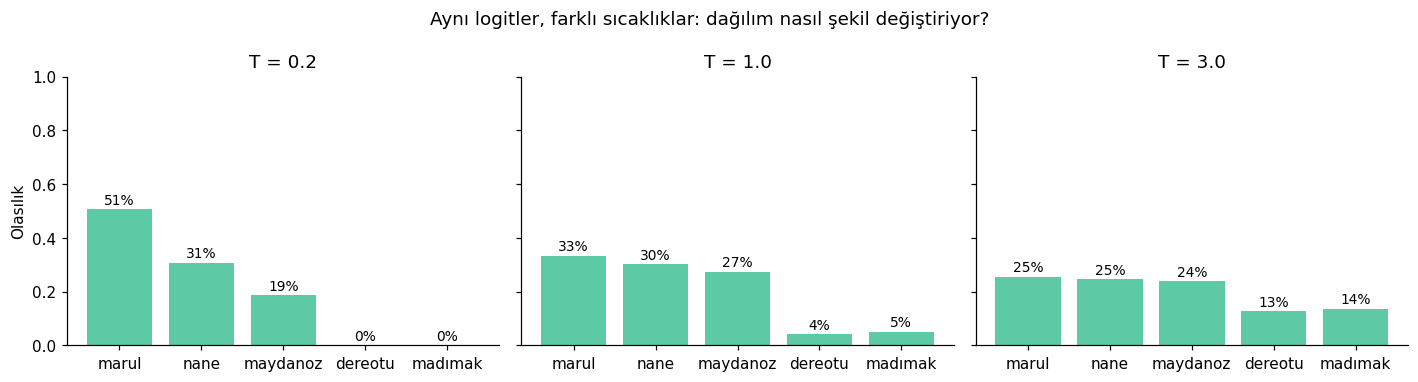

In [9]:
temperatures = [0.2, 1.0, 3.0]                                       # karşılaştırılacak üç sıcaklık değeri
fig, axes = plt.subplots(1, len(temperatures), figsize=(13, 3.5), sharey=True)  # yan yana 3 grafik alanı oluştur, y eksenini paylaştır

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, T)                       # bu sıcaklık için olasılıkları hesapla
    bars = ax.bar(kelimeler, probs, color="#5DCAA5")                    # her kelime için bir çubuk çiz
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)                                                   # y eksenini 0-1 (yüzde 0-100) aralığında sabitle
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02, f"{p:.0%}",  # çubuğun üstüne yüzde değerini yaz
                 ha="center", fontsize=9)

axes[0].set_ylabel("Olasılık")
fig.suptitle("Aynı logitler, farklı sıcaklıklar: dağılım nasıl şekil değiştiriyor?")
plt.tight_layout()
plt.show()


In [10]:
def greedy_index(probs):
    # En yüksek olasılığa sahip elemanın indeksini döndürür -> her zaman aynı seçim, rastgelelik yok
    return int(np.argmax(probs))


def temperature_sample_index(probs, rng):
    # probs dizisini ağırlık olarak kullanarak rastgele bir indeks çeker (zar atmak gibi)
    return int(rng.choice(len(probs), p=probs))


def top_k_index(probs, k, rng):
    k = min(k, len(probs))                      # k, eleman sayısından büyük olamaz
    top_idx = np.argsort(probs)[-k:]            # en yüksek k olasılığın indeksleri (küçükten büyüğe sıralayıp son k'yı al)
    top_probs = probs[top_idx]
    top_probs = top_probs / top_probs.sum()      # havuzu yeniden normalize et (toplamları yine 1 olsun)
    return int(rng.choice(top_idx, p=top_probs))  # sadece bu k'lık havuzdan örnekle


def top_p_index(probs, p, rng):
    order = np.argsort(probs)[::-1]              # büyükten küçüğe sırala
    sorted_probs = probs[order]
    cumulative = np.cumsum(sorted_probs)          # kümülatif (biriken) olasılık toplamı
    cutoff = int(np.searchsorted(cumulative, p)) + 1  # kümülatif toplam p'yi geçtiği ilk noktayı bul
    pool_idx = order[:cutoff]                     # havuz: kümülatif olasılığı p'ye getiren en olası kelimeler
    pool_probs = probs[pool_idx]
    pool_probs = pool_probs / pool_probs.sum()     # havuzu yeniden normalize et
    return int(rng.choice(pool_idx, p=pool_probs))  # sadece bu (değişken boyutlu) havuzdan örnekle


# Aynı dağılım üzerinde dört stratejiyi karşılaştıralım
probs_demo = softmax_with_temperature(logits, T=1.0)  # T=1.0: ölçeklenmemiş "ham" dağılım
rng = np.random.default_rng(7)                          # bu hücreye özel, sabit bir rastgelelik kaynağı

print("Dağılım:", dict(zip(kelimeler, np.round(probs_demo, 3))))
print("Greedy        ->", kelimeler[greedy_index(probs_demo)])
print("Temperature   ->", kelimeler[temperature_sample_index(probs_demo, rng)])
print("Top-k (k=2)   ->", kelimeler[top_k_index(probs_demo, 2, rng)])
print("Top-p (p=0.8) ->", kelimeler[top_p_index(probs_demo, 0.8, rng)])

Dağılım: {'marul': np.float64(0.334), 'nane': np.float64(0.302), 'maydanoz': np.float64(0.273), 'dereotu': np.float64(0.041), 'madımak': np.float64(0.05)}
Greedy        -> marul
Temperature   -> nane
Top-k (k=2)   -> marul
Top-p (p=0.8) -> maydanoz


In [11]:
corpus = """
Bugün hava oldukça sıcaktı. Bugün hava aniden serinledi. Bugün hava biraz kapalıydı.
Yarın hava çok bulutlu olacak. Yarın hava yağmurlu görünüyor. Yarın hava güneşli olabilir.
Dün hava erkenden karardı. Dün hava aniden açtı. Dün hava herkesi şaşırttı.
Kedi bahçede hızlıca koştu ve ağaca tırmandı. Kedi bahçede sütünü içti ve uyudu.
Kuş ağaçta neşeyle öttü ve uçtu. Kuş ağaçta yuva yaptı. Tavşan bahçede zıpladı ve kaçtı.
Tavşan havuç yedi ve gizlendi. Çocuklar odada neşeyle oynadı ve şarkı söyledi.
Çocuklar odada resim yaptı ve eğlendi. Öğrenciler sınıfta kitap okudu ve yazdı.
Öğrenciler sınıfta ders dinledi. Annem mutfakta nefis bir çorba pişirdi ve ikram etti.
Annem mutfakta taze yemek yaptı. Babam mutfakta tatlı hazırladı ve masaya koydu.
Babam mutfakta çay demledi. Sabah olunca güneş erkenden açtı ve odayı ısıttı.
Sabah olunca kuşlar uyandı. Akşam olunca sokak lambaları yandı ve etrafı aydınlattı.
Akşam olunca trafik yoğunlaştı. Gece olunca herkes derin bir uykuya daldı.
Gece olunca sokaklar tamamen sessizleşti. Herkes evinde huzurla dinlendi.
Herkes yarın için plan yaptı. Bugün zaman çok hızlı geçti ama güzel bir gündü.
"""

def tokenize(text):
    text = text.replace("İ", "i").replace("I", "ı")  # Türkçe büyük/küçük harf tuzağı: Python'ın varsayılan .lower() "İ"yi yanlış çevirir
    text = text.lower()                                # tüm metni küçük harfe çevir (aksi halde "Hava" ve "hava" farklı kelime sayılır)
    text = re.sub(r"[^\w\sçğıöşüâî]", " ", text, flags=re.UNICODE)  # noktalama işaretlerini boşlukla değiştir, Türkçe harfleri koru
    return text.split()                                  # boşluklardan böl -> kelime listesi döndür


tokens = tokenize(corpus)
print(f"Toplam token sayısı: {len(tokens)}")
print(f"Benzersiz kelime sayısı: {len(set(tokens))}")
print("İlk 15 token:", tokens[:15])

Toplam token sayısı: 172
Benzersiz kelime sayısı: 110
İlk 15 token: ['bugün', 'hava', 'oldukça', 'sıcaktı', 'bugün', 'hava', 'aniden', 'serinledi', 'bugün', 'hava', 'biraz', 'kapalıydı', 'yarın', 'hava', 'çok']


In [12]:
# Bigram sayım tablosu: bigram_counts["hava"] = {"çok": 2, "birden": 1, ...}
bigram_counts = {}
# zip(tokens[:-1], tokens[1:]) -> her kelimeyi kendinden sonraki kelimeyle eşler:
# [bugün, hava, çok, ...] üzerinde (bugün, hava), (hava, çok), ... çiftlerini gezer
for current_word, next_word in zip(tokens[:-1], tokens[1:]):
    bigram_counts.setdefault(current_word, {})                                   # bu kelime ilk kez görülüyorsa boş bir sözlük aç
    bigram_counts[current_word][next_word] = bigram_counts[current_word].get(next_word, 0) + 1  # sayacı bir artır

# "hava" kelimesinden sonra hangi kelimeler hangi sıklıkla geliyor?
print("'hava' kelimesinden sonra gözlenen kelimeler:")
for kelime, sayi in bigram_counts["hava"].items():
    print(f"  {kelime!r:<12} -> {sayi} kez")

'hava' kelimesinden sonra gözlenen kelimeler:
  'oldukça'    -> 1 kez
  'aniden'     -> 2 kez
  'biraz'      -> 1 kez
  'çok'        -> 1 kez
  'yağmurlu'   -> 1 kez
  'güneşli'    -> 1 kez
  'erkenden'   -> 1 kez
  'herkesi'    -> 1 kez


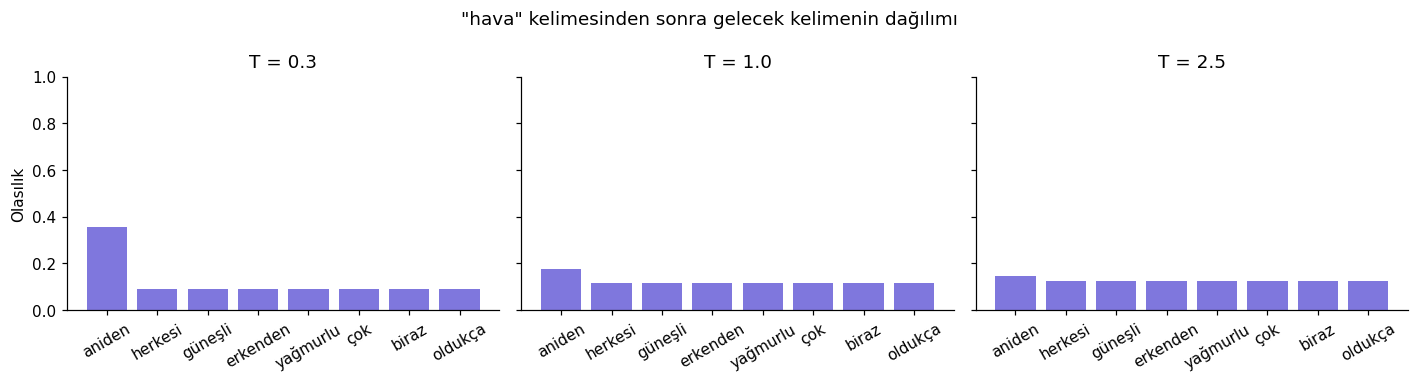

In [13]:
def predict_next_word(current_word, temperature=1.0):
    """current_word'den sonra gelebilecek kelimelerin (kelime_listesi, olasılık_dizisi) çiftini döndürür.
    current_word hiç görülmemişse None döner (zincir kopar)."""
    if current_word not in bigram_counts:
        return None                                                  # bu kelimeden sonrası hiç gözlenmedi -> tahmin yapılamaz
    candidates = list(bigram_counts[current_word].keys())              # bu kelimeden sonra gözlenen tüm farklı kelimeler
    counts = np.array([bigram_counts[current_word][c] for c in candidates], dtype=float)  # her birinin kaç kez gözlendiği
    pseudo_logits = np.log(counts + 1.0)           # sayım -> "logit" (log almak büyük sayım farklarını yumuşatır; +1 hiç görülmemiş ihtimale küçük bir pay bırakır)
    probs = softmax_with_temperature(pseudo_logits, temperature)  # sıcaklık uygulanmış softmax ile olasılığa çevir
    return candidates, probs


# "hava" kelimesi için farklı sıcaklıklarda dağılımı görselleştirelim
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, T in zip(axes, [0.3, 1.0, 2.5]):
    candidates, probs = predict_next_word("hava", T)        # bu sıcaklık için (kelime listesi, olasılık) çiftini al
    order = np.argsort(probs)[::-1]                          # en olasıdan en az olasıya doğru sırala (sadece görsel düzen için)
    ax.bar(np.array(candidates)[order], probs[order], color="#7F77DD")
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Olasılık")
fig.suptitle('"hava" kelimesinden sonra gelecek kelimenin dağılımı')
plt.tight_layout()
plt.show()

In [14]:
def generate(seed_word, steps=12, temperature=1.0, strategy="temperature", k=3, p=0.9, seed=None):
    """seed_word'den başlayıp, her adımda bir kelime tahmin edip örnekleyerek steps adım boyunca metin üretir.
    strategy: 'greedy' | 'temperature' | 'top_k' | 'top_p' — örnekleme stratejisini belirler.
    seed: rastgele sayı üretecinin tohumu (aynı seed -> aynı rastgele çıktı, tekrar üretilebilirlik için)."""
    rng = np.random.default_rng(seed)     # bu üretim için özel bir rastgelelik kaynağı
    current = seed_word.lower()            # girdi: zincirin başlangıç kelimesi
    sequence = [current]                   # üretilen tüm dizi burada birikecek

    for _ in range(steps):                  # döngü: toplam steps kez "tahmin et -> örnekle -> ekle" yap
        result = predict_next_word(current, temperature)   # tahmin: current'tan sonraki kelimelerin olasılık dağılımı
        if result is None:
            sequence.append("...[zincir koptu: bu kelimeden sonrası gözlenmedi]")
            break                                              # bigram tablosunda devamı yoksa döngüyü durdur

        candidates, probs = result

        # örnekleme: strategy parametresine göre dağılımdan bir indeks seç
        if strategy == "greedy":
            idx = greedy_index(probs)              # her zaman en olası kelime
        elif strategy == "top_k":
            idx = top_k_index(probs, k, rng)        # en olası k kelime arasından örnekle
        elif strategy == "top_p":
            idx = top_p_index(probs, p, rng)        # kümülatif olasılığı p'ye getiren havuzdan örnekle
        else:  # "temperature"
            idx = temperature_sample_index(probs, rng)  # tüm dağılımdan olasılıklara göre örnekle

        next_word = candidates[idx]    # seçilen kelime
        sequence.append(next_word)      # ekle: kelimeyi üretilen diziye ekle
        current = next_word             # <-- AUTOREGRESSION: çıktı, yeni girdi oluyor; döngü bu satırla "başa dönüyor"

    return " ".join(sequence)


print("Greedy (T etkisiz, her zaman en olası kelime):")
print(" ", generate("bugün", steps=14, strategy="greedy"))
print()
print("Temperature sampling, T=0.3 (tutucu):")
print(" ", generate("bugün", steps=14, temperature=0.3, seed=1))
print()
print("Temperature sampling, T=1.5 (yaratıcı/riskli):")
print(" ", generate("bugün", steps=14, temperature=1.5, seed=1))

Greedy (T etkisiz, her zaman en olası kelime):
  bugün hava aniden serinledi bugün hava aniden serinledi bugün hava aniden serinledi bugün hava aniden

Temperature sampling, T=0.3 (tutucu):
  bugün hava herkesi şaşırttı kedi bahçede sütünü içti ve eğlendi öğrenciler sınıfta ders dinledi annem

Temperature sampling, T=1.5 (yaratıcı/riskli):
  bugün hava herkesi şaşırttı kedi bahçede sütünü içti ve eğlendi öğrenciler sınıfta ders dinledi annem
